In [11]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set()
# đọc dữ liệu từ file csv
raw_path = '/content/drive/MyDrive/Đồ án deep/rawdata.csv'
data = pd.read_csv(raw_path, thousands=',', skipinitialspace=True)
# xem các phần tử đầu trong dữ liệu
data.head()


,DiaChi,TinhTrangBDS,DienTich,Gia/m2,Phongngu,TenPhanKhu,SoTang,PhongTam,Loai,GiayTo,MaCanHo,TinhTrangNoiThat,HuongCuaChinh,HuongBanCong,DacDiem,Gia
0,"Đường Nguyễn Văn Quỳ, Phường Phú Thuận, Quận 7...",Đã bàn giao,62 m²,"32,26 triệu/m²",2 phòng,NaN,NaN,2 phòng,Chung cư,Đã có sổ,NaN,NaN,NaN,NaN,NaN,2 tỷ- 62 m2đ
1,"Đường Nguyễn Văn Linh, Phường Tân Thuận Tây, Q...",Đã bàn giao,95 m²,"55,79 triệu/m²",3 phòng,NaN,NaN,2 phòng,Chung cư,Đang chờ sổ,NaN,Nội thất cao cấp,NaN,NaN,Căn góc,"5,3 tỷ- 95 m2đ"
2,"Đường Võ Văn Kiệt, Phường An Lạc, Quận Bình Tâ...",Chưa bàn giao,75 m²,"34,4 triệu/m²",2 phòng,2,5.0,2 phòng,Chung cư,Giấy tờ khác,17,NaN,Đông Nam,Đông Nam,NaN,"2,58 tỷ- 75 m2đ"
3,"108, Đường Hồng Hà, Phường 2, Quận Tân Bình, T...",Đã bàn giao,70 m²,"57,14 triệu/m²",1 phòng,A,7.0,1 phòng,Chung cư,Đang chờ sổ,BPA - 0712,Nội thất cao cấp,Đông Nam,Tây Bắc,NaN,4 tỷ- 70 m2đ
4,"Đường Hậu Giang, Phường 11, Quận 6, Tp Hồ Chí ...",Đã bàn giao,83 m²,"35,54 triệu/m²",2 phòng,NaN,NaN,2 phòng,Chung cư,Đã có sổ,NaN,Nội thất cao cấp,Tây Bắc,NaN,NaN,"2,95 tỷ- 83 m2đ"


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24949 entries, 0 to 24948
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DiaChi            24949 non-null  object 
 1   TinhTrangBDS      24924 non-null  object 
 2   DienTich          24917 non-null  object 
 3   Gia/m2            24916 non-null  object 
 4   Phongngu          24926 non-null  object 
 5   TenPhanKhu        7035 non-null   object 
 6   SoTang            6726 non-null   float64
 7   PhongTam          24388 non-null  object 
 8   Loai              24926 non-null  object 
 9   GiayTo            18852 non-null  object 
 10  MaCanHo           3358 non-null   object 
 11  TinhTrangNoiThat  12790 non-null  object 
 12  HuongCuaChinh     9370 non-null   object 
 13  HuongBanCong      8670 non-null   object 
 14  DacDiem           5601 non-null   object 
 15  Gia               24949 non-null  object 
dtypes: float64(1), object(15)
memory usage: 

In [13]:
data_clean = data.dropna(subset=['DienTich', 'Phongngu', 'PhongTam', 'Loai', 'DiaChi', 'Gia']).copy()

# Robust cleaning functions
def safe_float(val):
    try:
        return float(val)
    except:
        return np.nan

def clean_phong_ngu(val):
    try:
        val_str = str(val)
        if 'nhiều hơn' in val_str.lower():
            return safe_float(val_str.split(' ')[2]) + 1
        return safe_float(val_str.split(' ')[0])
    except:
        return np.nan

def clean_phong_tam(val):
    try:
        val_str = str(val)
        if 'nhiều hơn' in val_str.lower():
            return safe_float(val_str.split(' ')[2]) + 1
        return safe_float(val_str.split(' ')[0])
    except:
        return np.nan

In [14]:
def clean_gia(val):
    try:
        val_str = str(val)
        if 'GIÁ TỐT' in val_str:
            val_str = val_str.split('\n')[0]
        else:
            val_str = val_str.split('-')[0]

        if 'tỷ' in val_str:
            price = val_str.split(' ')[0].replace(',', '.')
            return round(float(price) * 1e9, 1)
        elif 'triệu' in val_str:
            price = val_str.split(' ')[0].replace(',', '.')
            return round(float(price) * 1e6, 1)
        else:
            return np.nan
    except:
        return np.nan

def extract_quan(address):
    try:
        parts = [p.strip() for p in str(address).split(',')]
        if len(parts) >= 2:
            return parts[-2]
        return ''
    except:
        return ''

In [15]:
# Apply cleaning
data_clean['DienTich'] = data_clean['DienTich'].astype(str).str.split(' ').str[0].astype(float)
data_clean['Phongngu'] = data_clean['Phongngu'].apply(clean_phong_ngu)
data_clean['PhongTam'] = data_clean['PhongTam'].apply(clean_phong_tam)
data_clean['Gia'] = data_clean['Gia'].apply(clean_gia)
data_clean = data_clean.dropna(subset=['Gia'])

data_clean['Quan'] = data_clean['DiaChi'].apply(extract_quan)
data_clean = data_clean[data_clean['Quan'].str.contains('Quận|Huyện', na=False)]

data_clean['USD'] = np.round(data_clean['Gia'] / 24000, 0)
data_clean = data_clean[(data_clean['DienTich'] <= 500) & (data_clean['SoTang'] <= 81)]
data_clean['log_price'] = np.log(data_clean['USD'])

print(f"Số lượng bản ghi sau khi làm sạch: {len(data_clean)}")

Số lượng bản ghi sau khi làm sạch: 6529


In [16]:
feature_cols = ['Quan', 'TinhTrangBDS', 'DienTich', 'Phongngu', 'SoTang', 'PhongTam', 'Loai']
X = data_clean[feature_cols]
y_log = data_clean['log_price']
y_usd = data_clean['USD']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train_log, y_test_log, y_train_usd, y_test_usd = train_test_split(
    X_encoded, y_log, y_usd, test_size=0.2, random_state=365
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=365),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=365)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_log)
    y_pred_log = model.predict(X_test_scaled)
    y_pred_usd = np.exp(y_pred_log)

    r2 = r2_score(y_test_log, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
    mae = mean_absolute_error(y_test_usd, y_pred_usd)

    results.append((name, r2, rmse, mae))

In [18]:
results_df = pd.DataFrame(results, columns=["Model", "R2 (log_price)", "RMSE (USD)", "MAE (USD)"])
print(results_df)

               Model  R2 (log_price)    RMSE (USD)     MAE (USD)
0  Linear Regression        0.218826  53156.333683  34003.783930
1   Ridge Regression        0.218813  53154.550849  34003.465248
2      Random Forest        0.124818  52367.584366  26779.046355
3  Gradient Boosting        0.200688  50143.247093  28917.693357


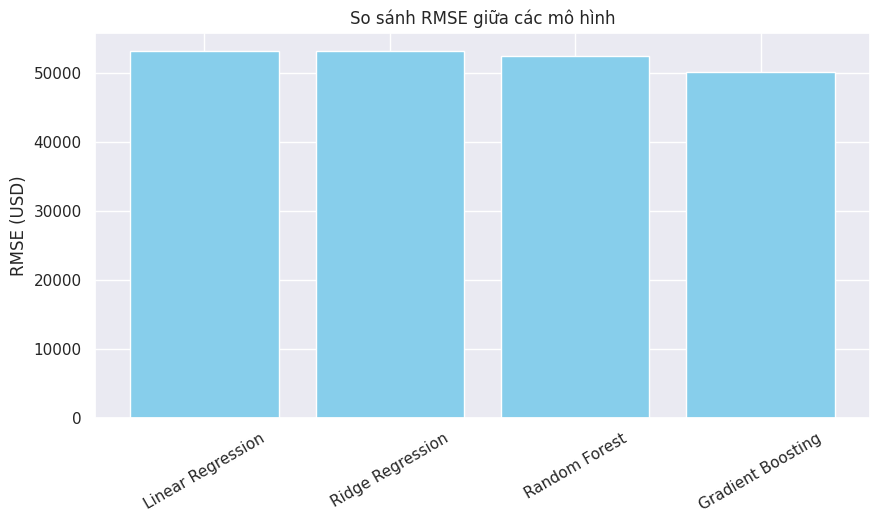

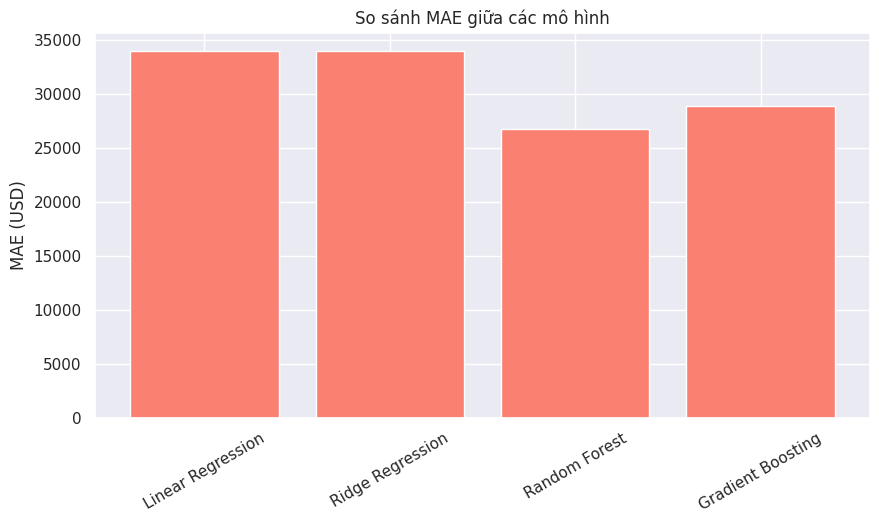

In [19]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ RMSE
plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['RMSE (USD)'], color='skyblue')
plt.title("So sánh RMSE giữa các mô hình")
plt.ylabel("RMSE (USD)")
plt.xticks(rotation=30)
plt.show()

# Vẽ biểu đồ MAE
plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['MAE (USD)'], color='salmon')
plt.title("So sánh MAE giữa các mô hình")
plt.ylabel("MAE (USD)")
plt.xticks(rotation=30)
plt.show()
